### Predicting Energy Consumption in Buildings

### Business Problem Statement: A building management company wants to predict energy consumption to optimize energy usage and reduce costs.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [3]:
building_data = pd.read_csv('building_energy_data.csv')

In [4]:
building_data.head(5)

,BuildingID,BuildingSize,BuildingAge,InsulationType,Temperature,Humidity,EnergyConsumption,SupplierLeadTime,RenewableEnergySource
0,B0001,910,51,Poor,35.347140,14.848393,136.438375,23,NaN
1,B0002,3822,54,Fair,-3.381381,64.831627,270.517752,10,Solar
2,B0003,3142,24,Poor,19.650725,11.997298,310.402460,11,NaN
3,B0004,516,25,Good,19.956029,23.714734,70.034617,6,Solar
4,B0005,4476,71,Good,7.673037,46.286320,412.368667,6,NaN


### Summary of Data

### Column Descriptions

`BuildingID`: Unique identifier for each building.

`BuildingSize`: Size of the building in square meters.

`BuildingAge`: Age of the building in years.

`InsulationType`: Quality of insulation (Poor, Fair, Good, Excellent).

`Temperature`: Average temperature in degrees Celsius.

`Humidity`: Average humidity percentage.

`EnergyConsumption`: Total energy consumed by the building in kWh.

`SupplierLeadTime`: Time it takes for energy suppliers to deliver new energy sources.

`RenewableEnergySource`: Type of renewable energy used (Solar, Wind, None).

## Issues with the Dataset

* The None value in the column RenewableEnergySource is treated as Nan(Null) value in the Data
* DataType for InsulationType and RenewableEnergySource can be changed
* RenewableEnergySource Column have missing values as the None value in the dataset are interpreted as Nan value but originally it should be None

In [5]:
building_data.tail()

,BuildingID,BuildingSize,BuildingAge,InsulationType,Temperature,Humidity,EnergyConsumption,SupplierLeadTime,RenewableEnergySource
995,B0996,3331,41,Fair,0.208328,71.513604,297.239697,23,NaN
996,B0997,524,89,Good,-7.882886,89.526532,110.995530,27,Solar
997,B0998,467,48,Poor,18.986308,10.886284,58.407917,21,Wind
998,B0999,3650,13,Excellent,12.645554,68.413876,479.146987,16,Wind
999,B1000,1004,73,Good,37.437220,55.743145,121.846910,9,Solar


In [6]:
building_data.sample(5)

,BuildingID,BuildingSize,BuildingAge,InsulationType,Temperature,Humidity,EnergyConsumption,SupplierLeadTime,RenewableEnergySource
789,B0790,2759,83,Excellent,28.240049,85.283861,411.452345,26,NaN
626,B0627,560,3,Good,0.733393,12.227513,85.886636,21,Solar
15,B0016,3435,85,Good,15.645121,69.245178,261.561236,12,Solar
466,B0467,4129,60,Good,3.450982,83.355364,641.806330,7,Solar
193,B0194,709,92,Good,29.812030,60.105788,155.978952,21,NaN


In [7]:
building_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   BuildingID             1000 non-null   object 
 1   BuildingSize           1000 non-null   int64  
 2   BuildingAge            1000 non-null   int64  
 3   InsulationType         1000 non-null   object 
 4   Temperature            1000 non-null   float64
 5   Humidity               1000 non-null   float64
 6   EnergyConsumption      1000 non-null   float64
 7   SupplierLeadTime       1000 non-null   int64  
 8   RenewableEnergySource  679 non-null    object 
dtypes: float64(3), int64(3), object(3)
memory usage: 70.4+ KB


In [8]:
missing_values = building_data.isnull().sum()
print(missing_values)

BuildingID                 0
BuildingSize               0
BuildingAge                0
InsulationType             0
Temperature                0
Humidity                   0
EnergyConsumption          0
SupplierLeadTime           0
RenewableEnergySource    321
dtype: int64


## **Data Cleaning**

 * Handling the Missing Values
 * Converting DataTypes

In [9]:
building_data['RenewableEnergySource'] = building_data['RenewableEnergySource'].fillna("None")

In [10]:
building_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   BuildingID             1000 non-null   object 
 1   BuildingSize           1000 non-null   int64  
 2   BuildingAge            1000 non-null   int64  
 3   InsulationType         1000 non-null   object 
 4   Temperature            1000 non-null   float64
 5   Humidity               1000 non-null   float64
 6   EnergyConsumption      1000 non-null   float64
 7   SupplierLeadTime       1000 non-null   int64  
 8   RenewableEnergySource  1000 non-null   object 
dtypes: float64(3), int64(3), object(3)
memory usage: 70.4+ KB


In [11]:
building_data.head(2)

,BuildingID,BuildingSize,BuildingAge,InsulationType,Temperature,Humidity,EnergyConsumption,SupplierLeadTime,RenewableEnergySource
0,B0001,910,51,Poor,35.347140,14.848393,136.438375,23,None
1,B0002,3822,54,Fair,-3.381381,64.831627,270.517752,10,Solar


In [12]:
building_data.duplicated().sum()

0

In [13]:
building_data.describe()

,BuildingSize,BuildingAge,Temperature,Humidity,EnergyConsumption,SupplierLeadTime
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,2578.250000,50.149000,15.902084,49.384810,296.190255,14.646000
std,1390.960625,28.855874,14.235700,23.318803,162.629420,8.362692
min,53.000000,1.000000,-9.977861,10.014922,27.606296,1.000000
25%,1389.500000,26.000000,4.136905,28.924968,166.374887,8.000000
50%,2647.000000,49.000000,16.586662,49.393253,273.275106,14.500000
75%,3693.250000,75.250000,28.069674,70.030764,403.408926,22.000000
max,4998.000000,99.000000,39.977196,89.809826,742.628282,29.000000


In [14]:
building_data['InsulationType'] = building_data['InsulationType'].astype('category')
building_data['RenewableEnergySource'] = building_data['RenewableEnergySource'].astype('category')

## EDA

### Performing Univariate Analysis on Numerical Columns

### BuildingSize

**conclusions**

* Most buildings are around 2600 m², with an average of about 2578 m²
* There's a big spread—from very small (53 m²) to very large (4998 m²) buildings
*While the mean and median hover around 2600–2650 m², the tallest histogram bin sits around 2900 m², indicating a popular size range in that interval
* The sizes are pretty evenly spread out, with no major skew or extreme outliers

In [15]:
summary_building_size = building_data['BuildingSize'].describe()
print("Summary Statistics for BuildingSize:")
print(summary_building_size)

Summary Statistics for BuildingSize:
count    1000.000000
mean     2578.250000
std      1390.960625
min        53.000000
25%      1389.500000
50%      2647.000000
75%      3693.250000
max      4998.000000
Name: BuildingSize, dtype: float64


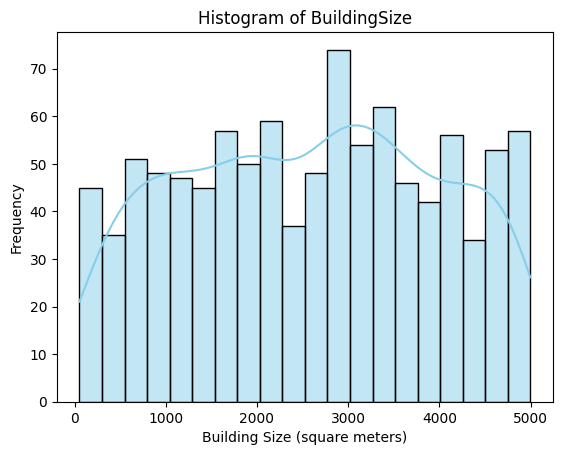

In [16]:
sns.histplot(building_data['BuildingSize'], bins=20, kde=True, color='skyblue')
plt.title('Histogram of BuildingSize')
plt.xlabel('Building Size (square meters)')
plt.ylabel('Frequency')
plt.show()

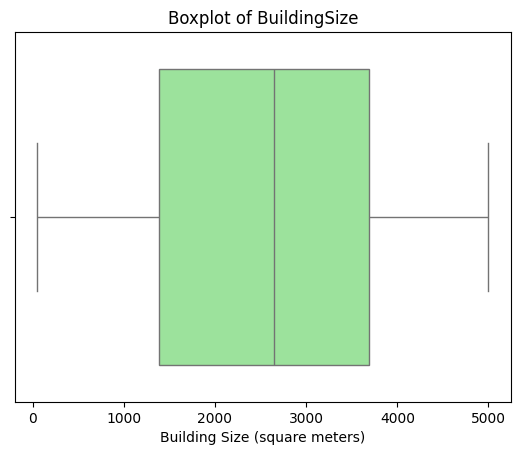

In [32]:
sns.boxplot(x=building_data['BuildingSize'], color='lightgreen')
plt.title('Boxplot of BuildingSize')
plt.xlabel('Building Size (square meters)')
plt.show()

In [33]:
skewness_building_size = building_data['BuildingSize'].skew()
kurtosis_building_size = building_data['BuildingSize'].kurtosis()

print("Skewness for BuildingSize:", skewness_building_size)
print("Kurtosis for BuildingSize:", kurtosis_building_size)

Skewness for BuildingSize: -0.026746101714582367
Kurtosis for BuildingSize: -1.1190233999402714


### BuildingAge

**conclusions**

* Most buildings are around 50 years old
* Although the summary stats center around 50, the highest frequency in the histogram occurs in the 35–40 age bin (with a frequency of 58), suggesting that a significant number of buildings are in that age range
* The ages range from 1 to 99 years, showing a decent spread.
* The distribution is pretty even almost no skew and a kurtosis, indicating no major age clusters or outliers

In [34]:
summary_building_age = building_data['BuildingAge'].describe()
print("Summary Statistics for BuildingAge:")
print(summary_building_age)

Summary Statistics for BuildingAge:
count    1000.000000
mean       50.149000
std        28.855874
min         1.000000
25%        26.000000
50%        49.000000
75%        75.250000
max        99.000000
Name: BuildingAge, dtype: float64


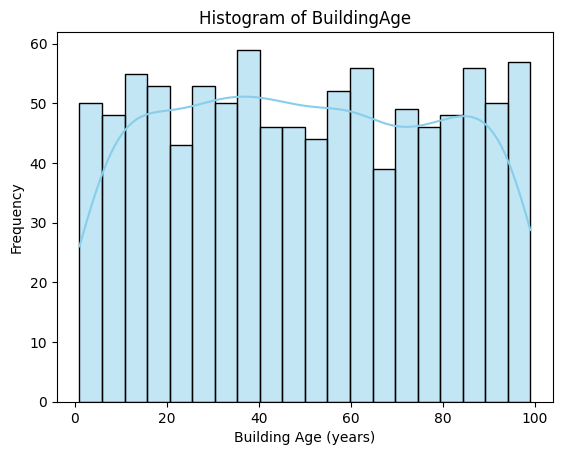

In [35]:
sns.histplot(building_data['BuildingAge'], bins=20, kde=True, color='skyblue')
plt.title('Histogram of BuildingAge')
plt.xlabel('Building Age (years)')
plt.ylabel('Frequency')
plt.show()

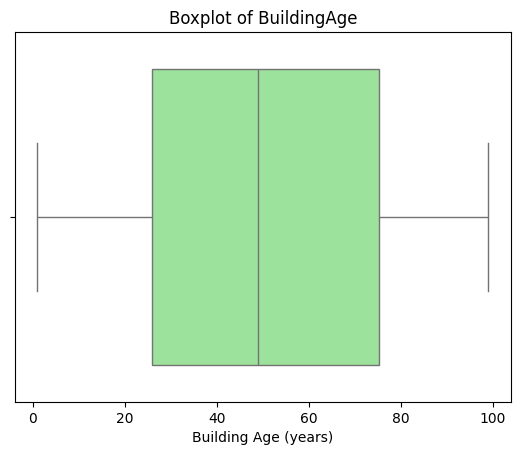

In [36]:
sns.boxplot(x=building_data['BuildingAge'], color='lightgreen')
plt.title('Boxplot of BuildingAge')
plt.xlabel('Building Age (years)')
plt.show()

In [37]:
skewness_building_age = building_data['BuildingAge'].skew()
print("Skewness for BuildingAge:", skewness_building_age)

Skewness for BuildingAge: 0.025476127544097154


In [38]:
kurtosis_building_age = building_data['BuildingAge'].kurt()
print("Kurtosis for BuildingAge:", kurtosis_building_age)

Kurtosis for BuildingAge: -1.1956404210237672


### Temperature

**conclusions**

* Most temperatures center around 16°C, which is pretty much our middle grounp
*  The distribution is nearly balanced and a bit flat, so there are no extreme spikes or drops.   

In [39]:
summary_temperature = building_data['Temperature'].describe()
print("Summary Statistics for Temperature:")
print(summary_temperature)

Summary Statistics for Temperature:
count    1000.000000
mean       15.902084
std        14.235700
min        -9.977861
25%         4.136905
50%        16.586662
75%        28.069674
max        39.977196
Name: Temperature, dtype: float64


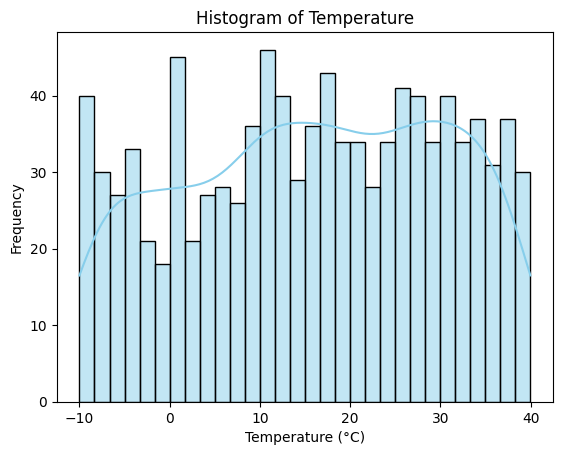

In [43]:
sns.histplot(building_data['Temperature'], bins=30, kde=True, color='skyblue')
plt.title('Histogram of Temperature')
plt.xlabel('Temperature (°C)')
plt.ylabel('Frequency')
plt.show()

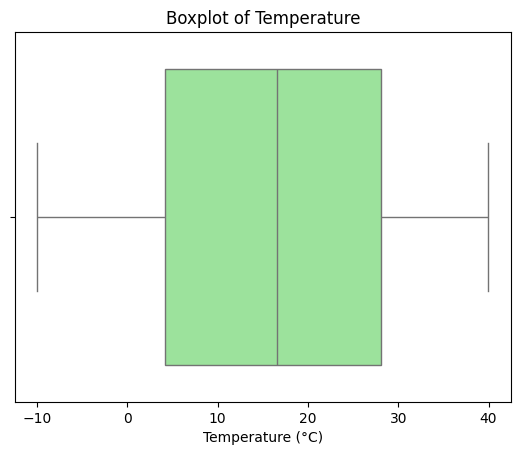

In [44]:
sns.boxplot(x=building_data['Temperature'], color='lightgreen')
plt.title('Boxplot of Temperature')
plt.xlabel('Temperature (°C)')
plt.show()

In [45]:
skewness_temperature = building_data['Temperature'].skew()
print("Skewness for Temperature:", skewness_temperature)

Skewness for Temperature: -0.12972739382361273


In [46]:
kurtosis_temperature = building_data['Temperature'].kurtosis()
print("Kurtosis for Temperature:", kurtosis_temperature)

Kurtosis for Temperature: -1.1191046471474617


### Humidity

**conclusions**

* Most readings cluster around 49% humidity, with a majority of values falling between roughly 29% and 70%
* The histogram and boxplot show a smooth, even spread with very few extreme values
* The near-zero skewness and slightly negative kurtosis confirm that the distribution is well-balanced

In [47]:
summary_humidity = building_data['Humidity'].describe()
print("Summary Statistics for Humidity:")
print(summary_humidity)

Summary Statistics for Humidity:
count    1000.000000
mean       49.384810
std        23.318803
min        10.014922
25%        28.924968
50%        49.393253
75%        70.030764
max        89.809826
Name: Humidity, dtype: float64


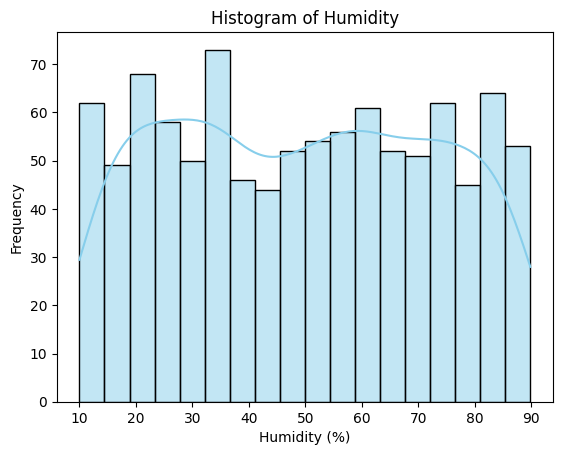

In [51]:
sns.histplot(building_data['Humidity'], bins=18, kde=True, color='skyblue')
plt.title('Histogram of Humidity')
plt.xlabel('Humidity')
plt.ylabel('Frequency')
plt.show()

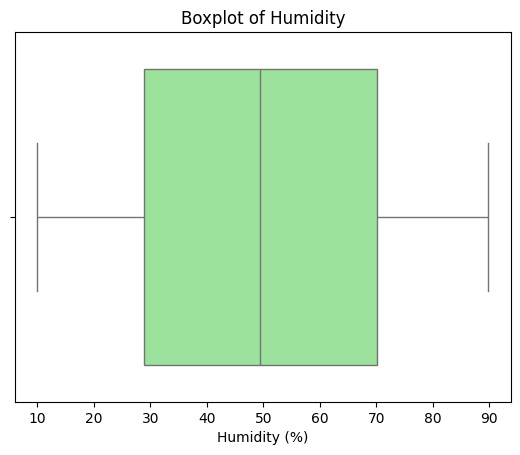

In [52]:
sns.boxplot(x=building_data['Humidity'], color='lightgreen')
plt.title('Boxplot of Humidity')
plt.xlabel('Humidity (%)')
plt.show()

In [53]:
skewness_humidity = building_data['Humidity'].skew()
print("Skewness for Humidity:", skewness_humidity)

Skewness for Humidity: 0.0301040001111682


In [54]:
kurtosis_humidity = building_data['Humidity'].kurtosis()
print("Kurtosis for Humidity:", kurtosis_humidity)

Kurtosis for Humidity: -1.2245222495317993


### SupplierLeadTime

**conclusions**

* Supplier lead times average around 14.6 days, with a median close to 14.5 days.
* Most suppliers deliver between 8 and 22 days, though the range spans from 1 to 29 days.
* The distribution is balanced, which suggests a fairly consistent delivery timeframe across suppliers.

In [55]:
summary_leadtime = building_data['SupplierLeadTime'].describe()
print("Summary Statistics for SupplierLeadTime:")
print(summary_leadtime)

Summary Statistics for SupplierLeadTime:
count    1000.000000
mean       14.646000
std         8.362692
min         1.000000
25%         8.000000
50%        14.500000
75%        22.000000
max        29.000000
Name: SupplierLeadTime, dtype: float64


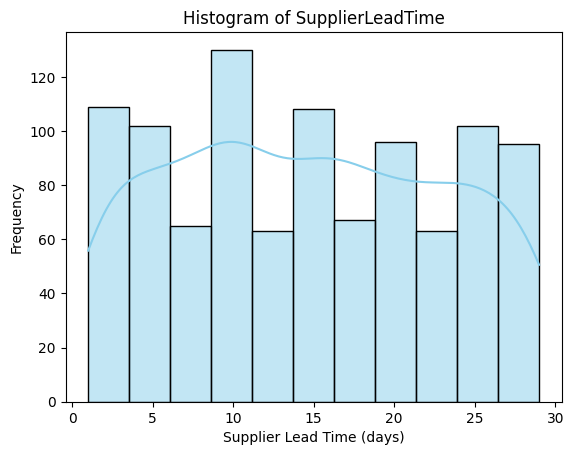

In [62]:
sns.histplot(building_data['SupplierLeadTime'], kde=True, color='skyblue')
plt.title('Histogram of SupplierLeadTime')
plt.xlabel('Supplier Lead Time (days)')
plt.ylabel('Frequency')
plt.show()

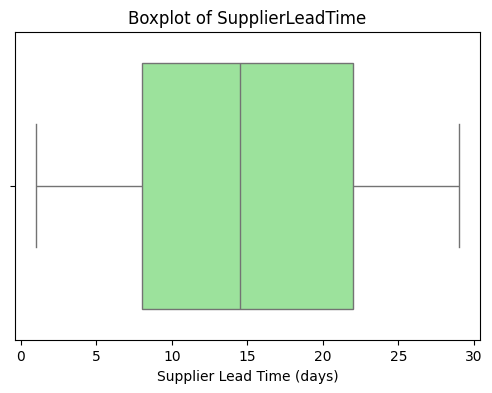

In [63]:
plt.figure(figsize=(6,4))
sns.boxplot(x=building_data['SupplierLeadTime'], color='lightgreen')
plt.title('Boxplot of SupplierLeadTime')
plt.xlabel('Supplier Lead Time (days)')
plt.show()

In [64]:
skewness_leadtime = building_data['SupplierLeadTime'].skew()
print("Skewness for SupplierLeadTime:", skewness_leadtime)

Skewness for SupplierLeadTime: 0.06921533932385447


In [65]:
kurtosis_leadtime = building_data['SupplierLeadTime'].kurtosis()
print("Kurtosis for SupplierLeadTime:", kurtosis_leadtime)

Kurtosis for SupplierLeadTime: -1.1566278663994336


### EnergyConsumption

**conclusions**

* Most buildings consume between 166 and 403 kWh (with a median around 273 kWh and mean close to 296 kWh) though the values range widely from about 28 to 743 kWh
* The distribution is moderately right-skewed (skew = 0.53), indicating that while most buildings have lower energy consumption, there are some that use significantly more

In [66]:
summary_energy = building_data['EnergyConsumption'].describe()
print(summary_energy)

count    1000.000000
mean      296.190255
std       162.629420
min        27.606296
25%       166.374887
50%       273.275106
75%       403.408926
max       742.628282
Name: EnergyConsumption, dtype: float64


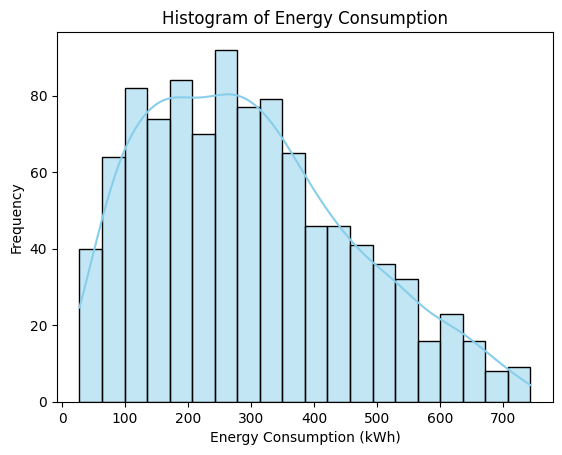

In [67]:
sns.histplot(building_data['EnergyConsumption'], bins=20, kde=True, color='skyblue')
plt.title('Histogram of Energy Consumption')
plt.xlabel('Energy Consumption (kWh)')
plt.ylabel('Frequency')
plt.show()

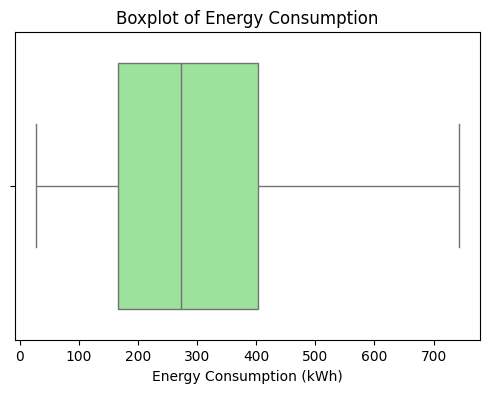

In [68]:
plt.figure(figsize=(6,4))
sns.boxplot(x=building_data['EnergyConsumption'], color='lightgreen')
plt.title('Boxplot of Energy Consumption')
plt.xlabel('Energy Consumption (kWh)')
plt.show()

In [69]:
skewness_energy = building_data['EnergyConsumption'].skew()
print("Skewness for EnergyConsumption:", skewness_energy)

Skewness for EnergyConsumption: 0.529793086329161


In [70]:
kurtosis_energy = building_data['EnergyConsumption'].kurtosis()
print("Kurtosis for EnergyConsumption:", kurtosis_energy)

Kurtosis for EnergyConsumption: -0.4422338484747095


### Univariate analysis on Categorical columns

### InsulationType

**conclusion**

* About 30.5% of the buildings have Good insulation and 29.2% have Fair insulation making these the two most common categories
* Poor insulation accounts for 21.2% of the buildings indicating a notable portion with lower insulation quality
* Only 19.1% of the buildings have Excellent insulation, suggesting that high-quality insulation is the least common among the categories

In [74]:
building_data['InsulationType'].value_counts()

,count
InsulationType,
Good,305
Fair,292
Poor,212
Excellent,191


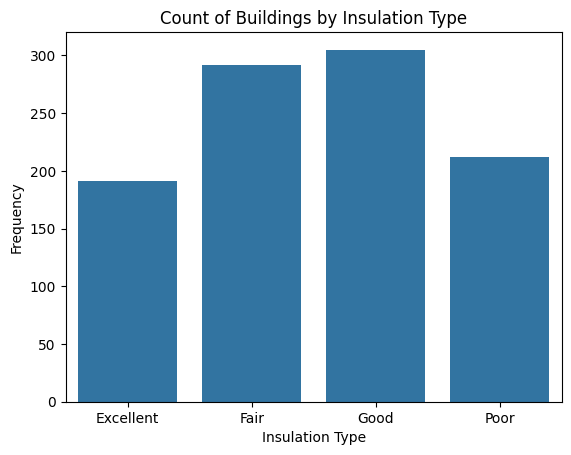

In [76]:
sns.countplot(data=building_data, x='InsulationType')
plt.title('Count of Buildings by Insulation Type')
plt.xlabel('Insulation Type')
plt.ylabel('Frequency')
plt.show()

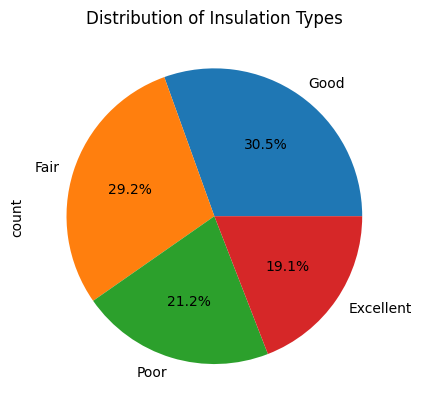

In [77]:
building_data['InsulationType'].value_counts().plot(kind='pie', autopct ='%0.1f%%')
plt.title('Distribution of Insulation Types')
plt.show()

### RenewableEnergySource

**conclusions**

* About 37.4% of the buildings use Solar energy, making it the most common renewable source in the dataset
* Approximately 32.1% of the buildings have no renewable energy, while 30.5% use Wind
* This near balance among the categories offers a good basis for comparing energy consumption across different renewable energy setups

In [78]:
building_data['RenewableEnergySource'].value_counts()

,count
RenewableEnergySource,
Solar,374
None,321
Wind,305


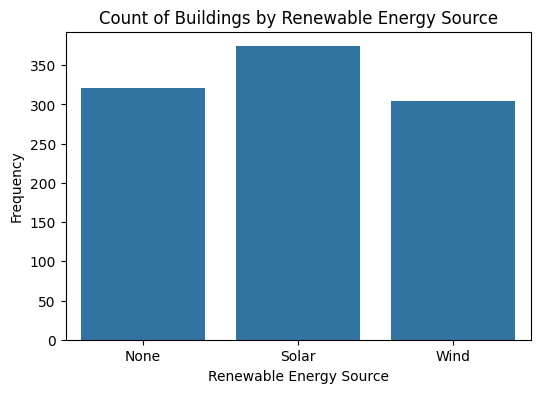

In [81]:
plt.figure(figsize=(6,4))
sns.countplot(data=building_data, x='RenewableEnergySource')
plt.title('Count of Buildings by Renewable Energy Source')
plt.xlabel('Renewable Energy Source')
plt.ylabel('Frequency')
plt.show()

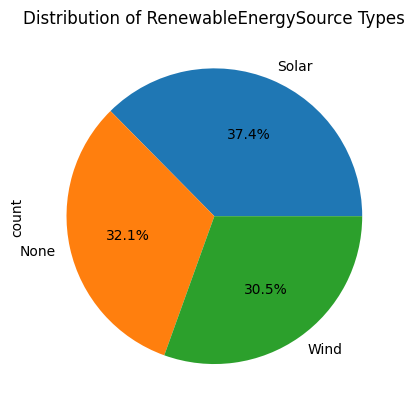

In [82]:
building_data['RenewableEnergySource'].value_counts().plot(kind='pie', autopct ='%0.1f%%')
plt.title('Distribution of RenewableEnergySource Types')
plt.show()

### Performing Bivariate Analysis

### EnergyConsumption vs. BuildingSize

**conclusions**

* We have a strong positive correlation (0.85) between building size and energy consumption, meaning bigger buildings generally use more energy
* The scatter plot makes it clear: as the building size goes up, energy consumption goes up too
* This tells us building size is a major factor in forecasting energy needs and should be a focus in efficiency planning

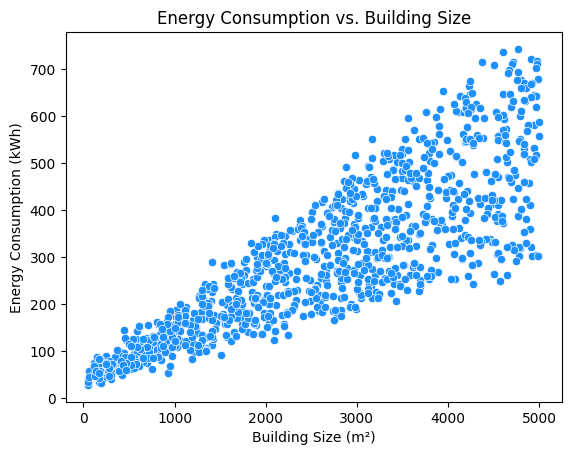

In [4]:
sns.scatterplot(data=building_data, x='BuildingSize', y='EnergyConsumption', color='dodgerblue')
plt.title('Energy Consumption vs. Building Size')
plt.xlabel('Building Size (m²)')
plt.ylabel('Energy Consumption (kWh)')
plt.show()

In [5]:
corr_size = building_data['BuildingSize'].corr(building_data['EnergyConsumption'])
print("Correlation (BuildingSize & EnergyConsumption):", corr_size)

Correlation (BuildingSize & EnergyConsumption): 0.8516230291177689


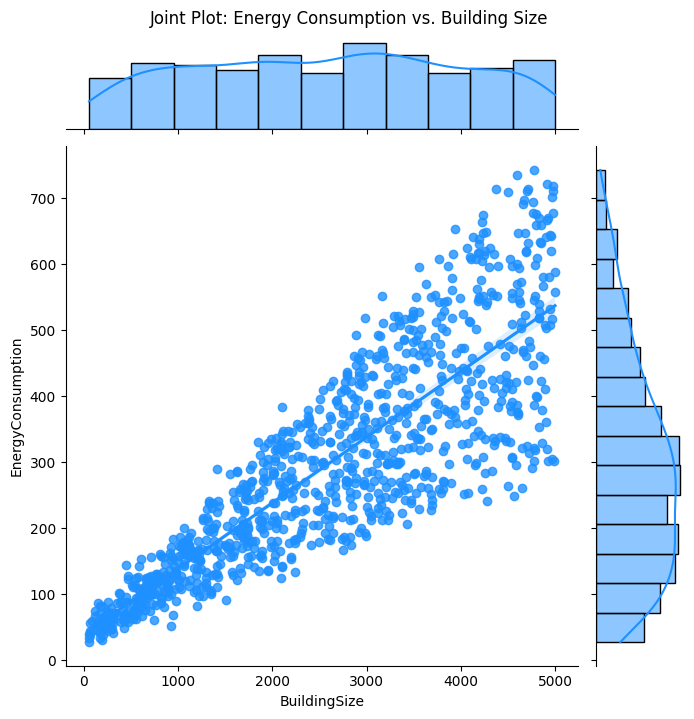

In [8]:
sns.jointplot(data=building_data, x='BuildingSize', y='EnergyConsumption', kind='reg', height=7, color='dodgerblue')
plt.suptitle('Joint Plot: Energy Consumption vs. Building Size', y=1.02)
plt.show()

### EnergyConsumption vs. BuildingAge

**conclusions**
* The correlation between building age and energy consumption is almost negligible (0.06), suggesting that age doesn't have a strong direct impact on energy use
* The scatter plot shows a very scattered pattern, with no clear trend as buildings get older

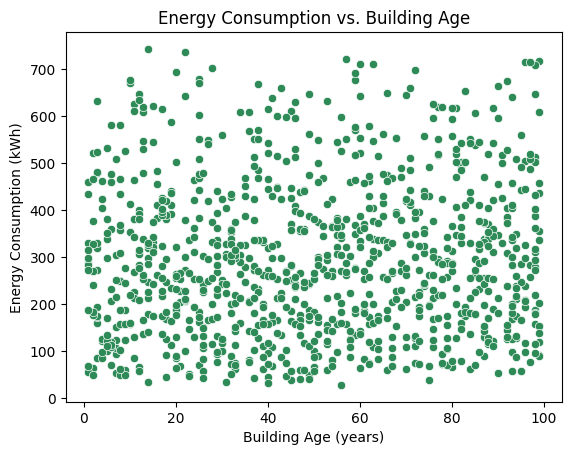

In [9]:
sns.scatterplot(data=building_data, x='BuildingAge', y='EnergyConsumption', color='seagreen')
plt.title('Energy Consumption vs. Building Age')
plt.xlabel('Building Age (years)')
plt.ylabel('Energy Consumption (kWh)')
plt.show()

In [10]:
corr_age = building_data['BuildingAge'].corr(building_data['EnergyConsumption'])
print("Correlation (BuildingAge & EnergyConsumption):", corr_age)

Correlation (BuildingAge & EnergyConsumption): 0.061204251687402185


### EnergyConsumption vs. Temperature

**conclusions**

* temperature doesn't seem to affect energy consumption much—the correlation is barely there (0.09)
* The scatter plot looks pretty random, with no clear trend linking temperature to how much energy is used

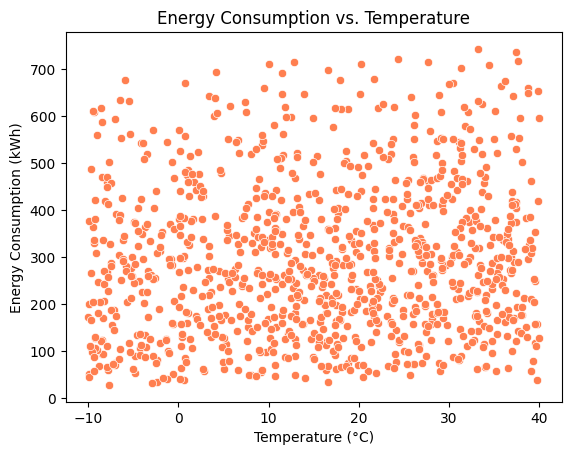

In [12]:
sns.scatterplot(data=building_data, x='Temperature', y='EnergyConsumption', color='coral')
plt.title('Energy Consumption vs. Temperature')
plt.xlabel('Temperature (°C)')
plt.ylabel('Energy Consumption (kWh)')
plt.show()

In [13]:
corr_temp = building_data['Temperature'].corr(building_data['EnergyConsumption'])
print("Correlation (Temperature & EnergyConsumption):", corr_temp)

Correlation (Temperature & EnergyConsumption): 0.09307973733195274


### EnergyConsumption vs. Humidity

**conclusions**

* The correlation between humidity and energy consumption is pretty low, suggesting that humidity isn't really pushing energy use up or down
* The scatter plot looks pretty scattered, with no clear pattern—so humidity doesn't seem to be a major factor here either

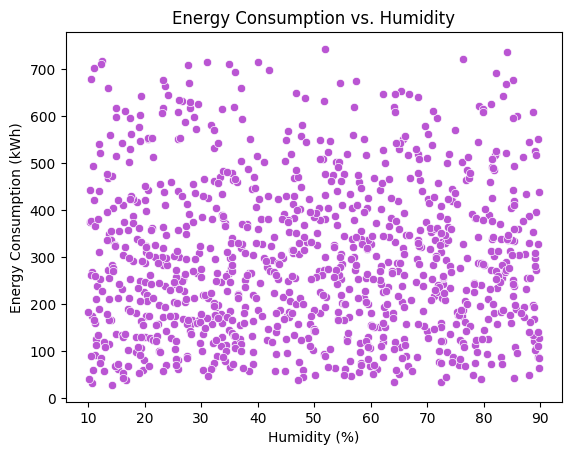

In [14]:
sns.scatterplot(data=building_data, x='Humidity', y='EnergyConsumption', color='mediumorchid')
plt.title('Energy Consumption vs. Humidity')
plt.xlabel('Humidity (%)')
plt.ylabel('Energy Consumption (kWh)')
plt.show()

In [15]:
corr_humidity = building_data['Humidity'].corr(building_data['EnergyConsumption'])
print("Correlation (Humidity & EnergyConsumption):", corr_humidity)

Correlation (Humidity & EnergyConsumption): 0.017157917252471438


### EnergyConsumption vs. InsulationType

**conclusions**

* It looks like buildings with “Excellent” insulation tend to use a bit less energy, though there’s still overlap with the other groups
* “Poor” insulation has a couple of buildings hitting really high usage, but on average, it’s not drastically higher than “Fair” or “Good”
* Overall, insulation quality seems to matter, but it’s not the only factor driving energy consumption

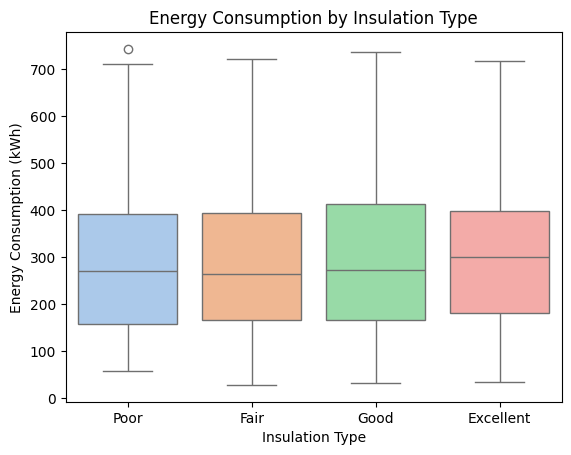

In [17]:
sns.boxplot(data=building_data, x='InsulationType', y='EnergyConsumption', hue='InsulationType', palette='pastel')
plt.title('Energy Consumption by Insulation Type')
plt.xlabel('Insulation Type')
plt.ylabel('Energy Consumption (kWh)')
plt.show()

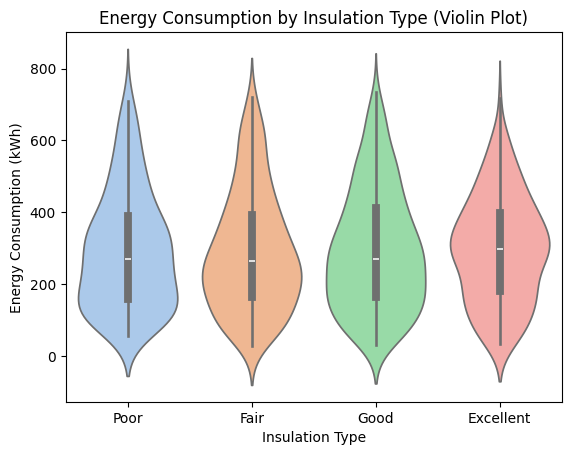

In [19]:
sns.violinplot(data=building_data, x='InsulationType', y='EnergyConsumption',hue='InsulationType', palette='pastel')
plt.title('Energy Consumption by Insulation Type (Violin Plot)')
plt.xlabel('Insulation Type')
plt.ylabel('Energy Consumption (kWh)')
plt.show()

### EnergyConsumption vs. RenewableEnergySource

**conclusions**

* “None” shows the widest range, with a few buildings going over 700 kWh, though most cluster around 300 kWh
* “Solar” has a slightly narrower spread, hovering around 250–300 kWh
* “Wind” seems to have the lowest median, hanging in the low 200s, but still stretching up near 600 kWh
* Overall, buildings with renewables trend a bit lower on energy use, but the gap isn’t huge

In [37]:
print(building_data['RenewableEnergySource'].value_counts())

RenewableEnergySource
Solar    374
None     321
Wind     305
Name: count, dtype: int64


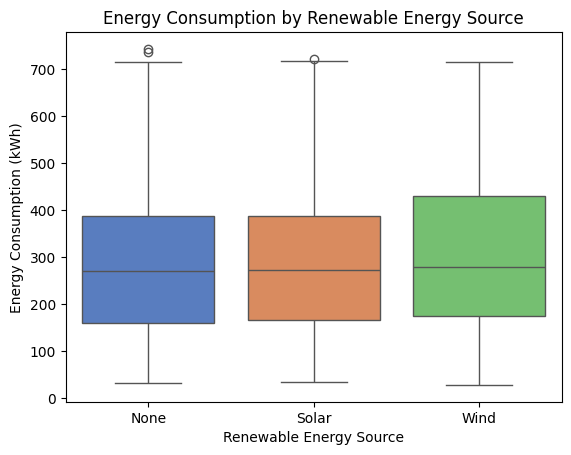

In [40]:
sns.boxplot(data=building_data, x='RenewableEnergySource', y='EnergyConsumption',hue='RenewableEnergySource', palette='muted')
plt.title('Energy Consumption by Renewable Energy Source')
plt.xlabel('Renewable Energy Source')
plt.ylabel('Energy Consumption (kWh)')
plt.show()

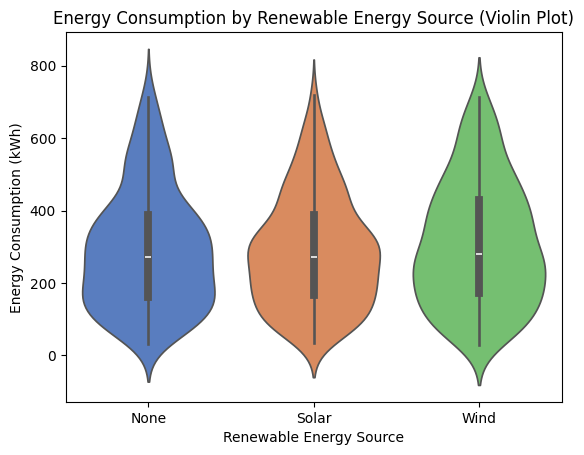

In [ ]:
sns.violinplot(data=building_data, x='RenewableEnergySource', y='EnergyConsumption',hue='RenewableEnergySource', palette='muted')
plt.title('Energy Consumption by Renewable Energy Source (Violin Plot)')
plt.xlabel('Renewable Energy Source')
plt.ylabel('Energy Consumption (kWh)')
plt.show()

### Performing Multivariate analysis


**conclusions**

The combined analysis shows that insulation quality and renewable energy type, whether looked at individually or together, don't seem to drive energy consumption much. Instead, building size appears to be the primary factor influencing energy use

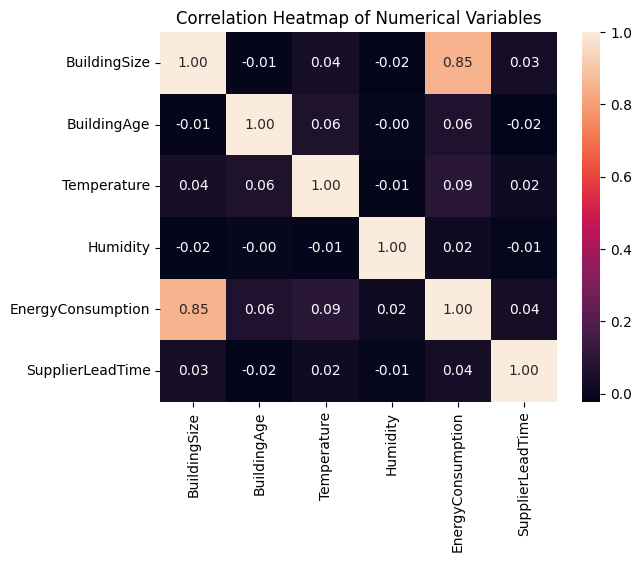

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

num_cols = ['BuildingSize', 'BuildingAge', 'Temperature', 'Humidity', 'EnergyConsumption', 'SupplierLeadTime']

corr_matrix = building_data[num_cols].corr()

sns.heatmap(corr_matrix, annot=True, fmt=".2f")
plt.title('Correlation Heatmap of Numerical Variables')
plt.show()


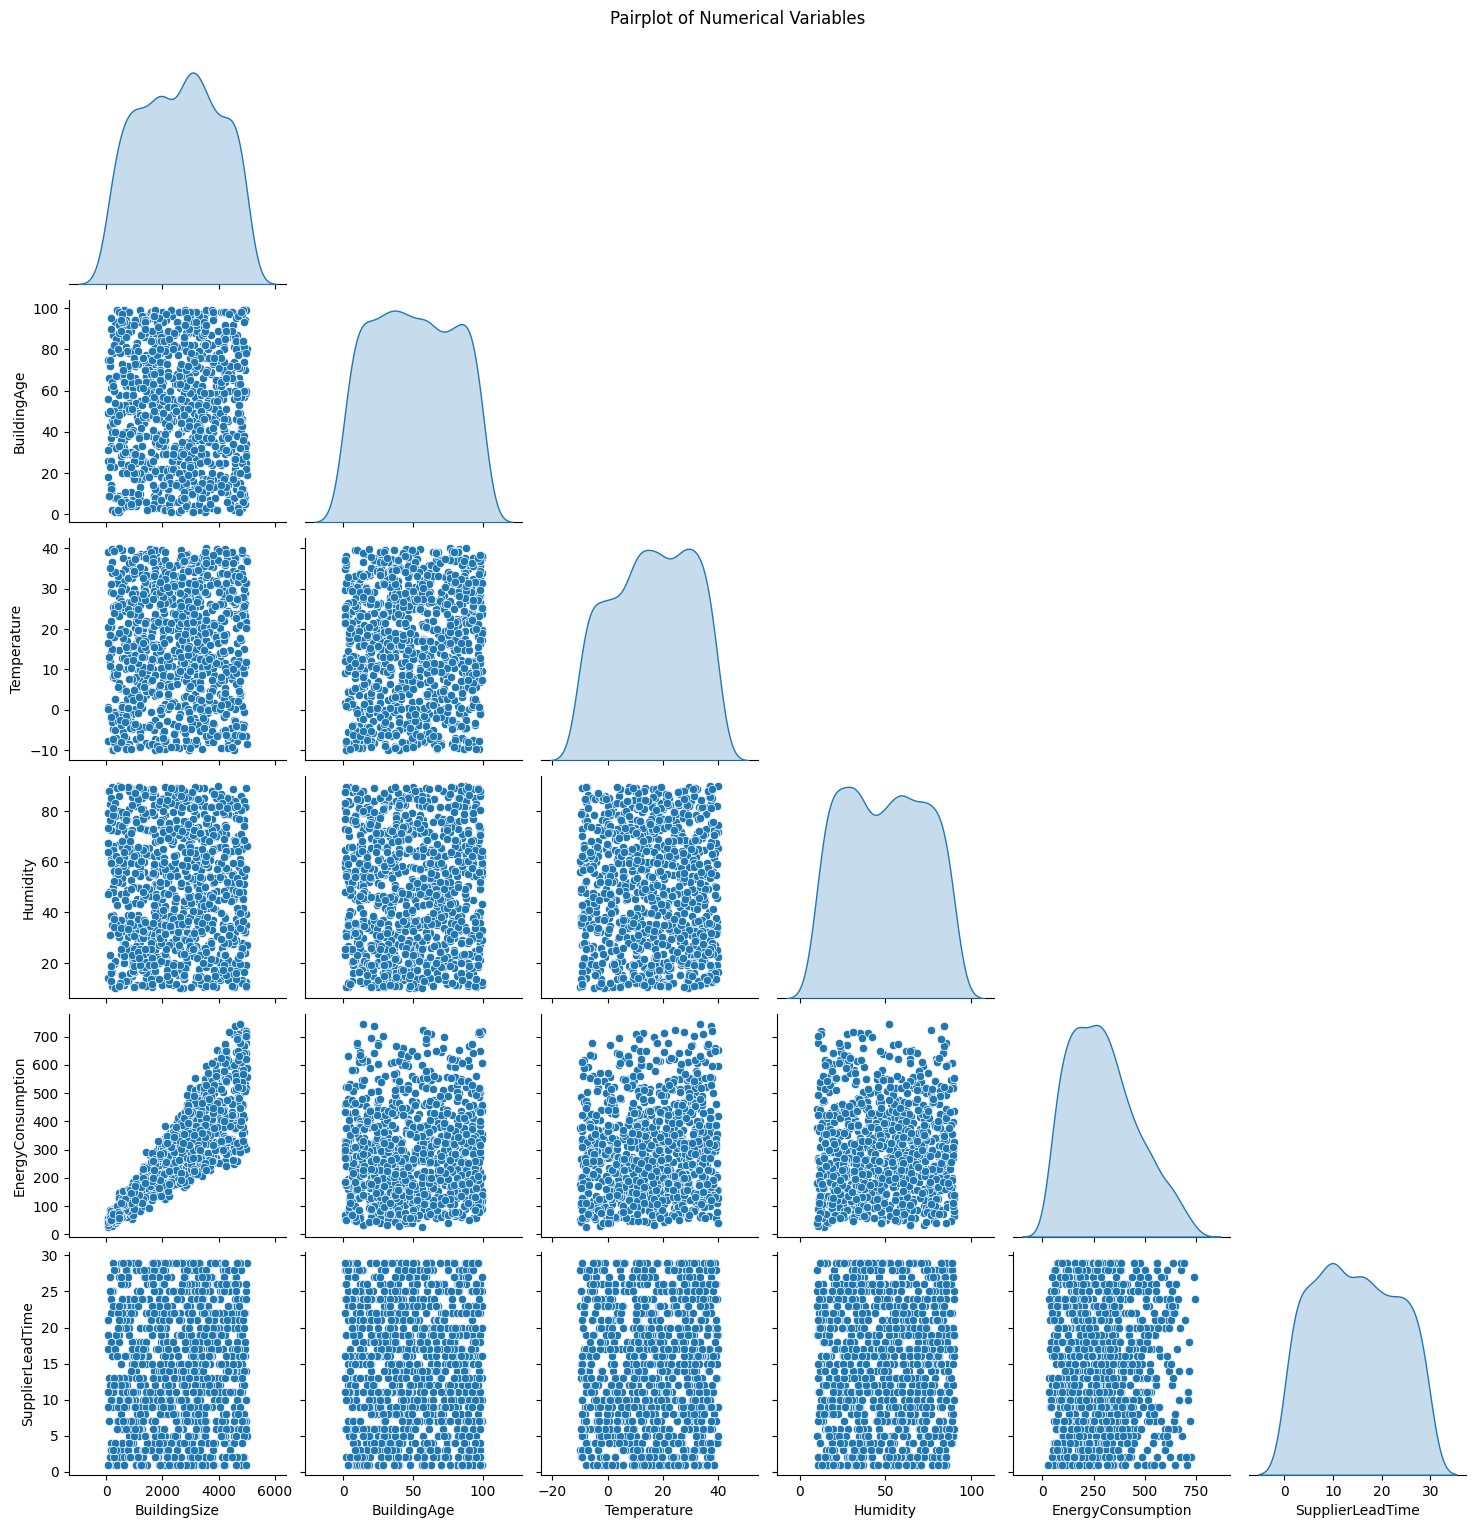

In [18]:
sns.pairplot(building_data[num_cols], diag_kind='kde', corner=True)
plt.suptitle('Pairplot of Numerical Variables', y=1.02)
plt.show()

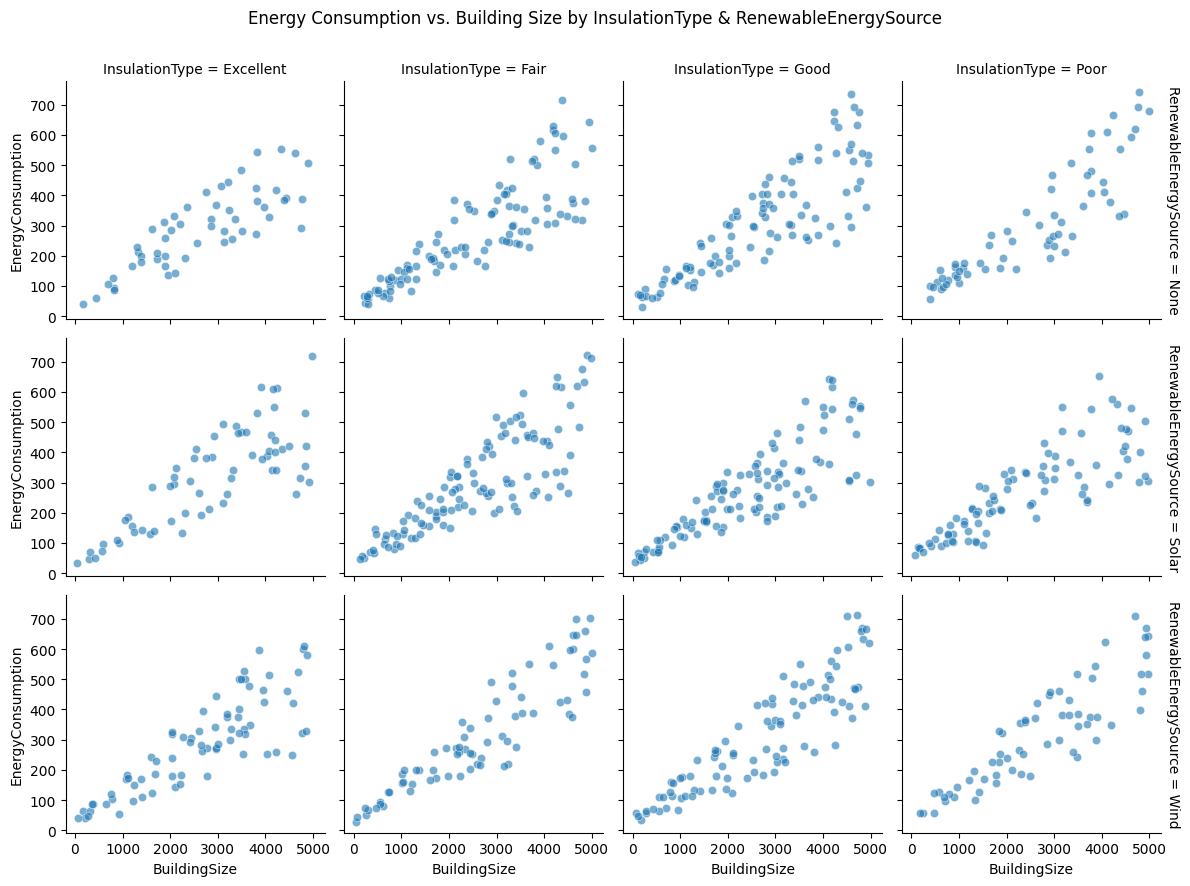

In [19]:
g = sns.FacetGrid(building_data, col="InsulationType", row="RenewableEnergySource", margin_titles=True, height=3)
g.map(sns.scatterplot, "BuildingSize", "EnergyConsumption", alpha=0.6)
g.fig.subplots_adjust(top=0.9)
g.fig.suptitle("Energy Consumption vs. Building Size by InsulationType & RenewableEnergySource")
plt.show()

# Final Conclusion



Findings
--------------------------------------------------
- BuildingSize: There is a strong link; larger buildings use considerably more energy
- Other Variables: Building age, temperature, humidity, insulation quality, and renewable energy type show little to no impact on energy consumption.
- Overall: The dominant insight is that building size is the key driver of energy usage, with the other factors only adding minor variations

--------------------------------------------------
Recommendations
--------------------------------------------------
- Focus on large buildings for energy management and efficiency improvements, as these structures are the main energy consumers
- Conduct targeted energy audits and consider retrofitting large buildings with more efficient HVAC and lighting systems
- While insulation and renewable energy factors didn’t show significant effects in this dataset, they might still be relevant in specific contexts. Consider further exploration or segmentation if more detailed data becomes available

--------------------------------------------------
Implications for Energy Management
--------------------------------------------------
- Strategic Prioritization: Energy efficiency measures should prioritize larger buildings since they account for the majority of energy use
- Cost Efficiency: Investments in energy-saving measures for large buildings are likely to yield higher returns

---------------------------------------------------
Next Steps
---------------------------------------------------
- we can Consider segmentation or clustering techniques to identify subgroups of large buildings with distinct energy consumption patterns
- As more detailed data becomes available, investigate additional variables that could further explain variations in energy usage